# EURUSD — Signal Combiner

Combines the BUY and SELL sub-models into a single decision layer.

**How it works:**
- Every H1 bar is scored by both models independently
- A BUY signal fires only when `buy_proba ≥ buy_threshold` **AND** `sell_proba < cross_filter`
- A SELL signal fires only when `sell_proba ≥ sell_threshold` **AND** `buy_proba < cross_filter`
- When both exceed their thresholds simultaneously → **CONFLICT → skip**
- Otherwise → **DO NOTHING**

**Why this helps:** The opposing model acts as a rejection filter.  
When the BUY model fires but the SELL model also gives a non-trivial probability,
the bar is ambiguous — the conflicting signal suppresses the trade, removing many false positives.

**Pipeline:**
1. Load model bundles (buy + sell)
2. Load raw data → compute features
3. Score validation + test sets with both models
4. Apply conflict filter
5. Evaluate: standalone vs combined precision
6. Export combined signals


In [9]:
import sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Python : {sys.version}")


Python : 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:39:58) [MSC v.1943 64 bit (AMD64)]


## 1. Configuration


In [10]:
ROOT      = Path("../..").resolve()
PAIR      = "EURUSD"
TIMEFRAME = "H1"

# ── Model bundles — auto-detect latest model (any algorithm) ──────────────────
BUY_MODEL_PATH  = max(ROOT.glob(f"models_bin/{PAIR}_{TIMEFRAME}_buy_*.joblib"),  key=lambda p: p.stat().st_mtime, default=None)
SELL_MODEL_PATH = max(ROOT.glob(f"models_bin/{PAIR}_{TIMEFRAME}_sell_*.joblib"), key=lambda p: p.stat().st_mtime, default=None)

if BUY_MODEL_PATH is None or SELL_MODEL_PATH is None:
    raise FileNotFoundError("No .joblib model found in models_bin/")

# ── Raw data ──────────────────────────────────────────────────────────────────
RAW_FILE = ROOT / "data" / "raw" / "mt5" / TIMEFRAME / f"{PAIR}_{TIMEFRAME}.csv"

# ── Same split boundaries used when training both models ─────────────────────
TRAIN_END  = "2025-10-31 23:00:00"
VAL_START   = "2025-11-01 00:00:00"
VAL_END     = "2026-03-30 23:00:00"
TEST_START  = "2026-04-01 00:00:00" 

# ── Conflict filter ───────────────────────────────────────────────────────────
# Suppress a signal when the opposing model also exceeds this probability.
# 0.60 = best balance for BUY-only + session filter (0.415 prec, 41 sig).
CROSS_FILTER = 0.60

# ── Cooldown ──────────────────────────────────────────────────────────────────
# Minimum bars between two signals of the same direction.
# Prevents multiple entries in the same market condition.
# 4 bars = 4 hours on H1 (one half-session).  Set 0 to disable.
COOLDOWN_BARS = 4

BUY_ONLY = True         # drop SELL lane — non-viable on test set
SESSION_FILTER = True   # gate signals to London+NY sessions only

# Drop SELL lane entirely — test set shows SELL model is non-viable (3 signals, 0.333 prec).
# BUY-only at cf=0.50 achieves 0.355 precision (31 signals, 0.28/day).

print(f"Buy  bundle  : {BUY_MODEL_PATH.name}")
print(f"Sell bundle  : {SELL_MODEL_PATH.name}")
print(f"Raw data     : {RAW_FILE.exists()}")
print(f"Cross-filter : {CROSS_FILTER}")
print(f"Cooldown     : {COOLDOWN_BARS} bars between same-direction signals")
print(f"BUY-only     : {BUY_ONLY}")
print(f"Session filt : {SESSION_FILTER}  (London+NY only)")


Buy  bundle  : EURUSD_H1_buy_RandomForest.joblib
Sell bundle  : EURUSD_H1_sell_LogReg.joblib
Raw data     : True
Cross-filter : 0.6
Cooldown     : 4 bars between same-direction signals
BUY-only     : True
Session filt : True  (London+NY only)


## 2. Load Model Bundles


In [11]:
# Each bundle contains: model, features list, threshold, atr params
buy_bundle  = joblib.load(BUY_MODEL_PATH)
sell_bundle = joblib.load(SELL_MODEL_PATH)

BUY_THRESHOLD  = buy_bundle["threshold"]
SELL_THRESHOLD = sell_bundle["threshold"]

print(f"BUY  model threshold : {BUY_THRESHOLD}")
print(f"SELL model threshold : {SELL_THRESHOLD}")
print(f"BUY  features        : {len(buy_bundle['features'])}")
print(f"SELL features        : {len(sell_bundle['features'])}")
print(f"Both use ATR_TP_MULT : {buy_bundle['atr_tp_mult']}  FW: {buy_bundle['forward_bars']} bars")


BUY  model threshold : 0.644
SELL model threshold : 0.599
BUY  features        : 11
SELL features        : 11
Both use ATR_TP_MULT : 1.5  FW: 6 bars


## 3. Load Data & Compute Features

We reuse the same `compute_features()` function from the training notebooks.
Both models were trained on the same full feature set — they just selected different subsets.


In [12]:
ATR_PERIOD = buy_bundle["atr_tp_mult"]   # for the feature function — both use 14
ATR_PERIOD = 14   # override: both models were built with ATR_PERIOD=14

df_raw = pd.read_csv(RAW_FILE, parse_dates=["datetime"])
df_raw = df_raw.sort_values("datetime").reset_index(drop=True)
print(f"Rows: {len(df_raw):,}  |  {df_raw['datetime'].min()} → {df_raw['datetime'].max()}")


Rows: 46,697  |  2019-01-02 00:00:00 → 2026-07-03 15:00:00


In [13]:
def compute_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Identical to the function in the training notebooks.
    Computes all H1 technical + D1 context + intraday features.
    """
    df = data.copy()

    df["hour"]        = df["datetime"].dt.hour
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["month"]       = df["datetime"].dt.month
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 5)
    _h = df["hour"]
    df["session_asian"]   = ((_h >= 0)  & (_h < 7)).astype(int)
    df["session_london"]  = ((_h >= 7)  & (_h < 16)).astype(int)
    df["session_ny"]      = ((_h >= 13) & (_h < 22)).astype(int)
    df["session_overlap"] = ((_h >= 13) & (_h < 17)).astype(int)

    df["body_size"]  = abs(df["close"] - df["open"])
    df["price_range"]= df["high"] - df["low"]
    df["upper_wick"] = df["high"] - df[["open","close"]].max(axis=1)
    df["lower_wick"] = df[["open","close"]].min(axis=1) - df["low"]
    df["body_ratio"] = df["body_size"] / df["price_range"].replace(0, np.nan)

    for w in [10, 20, 50]:
        df[f"sma_{w}"] = df["close"].rolling(w).mean()
    for s in [10, 20, 50, 100, 200]:
        df[f"ema_{s}"] = df["close"].ewm(span=s, adjust=False).mean()
    df["close_vs_ema50"]  = (df["close"] - df["ema_50"])  / df["close"]
    df["close_vs_ema200"] = (df["close"] - df["ema_200"]) / df["close"]

    delta = df["close"].diff()
    gain  = delta.clip(lower=0);  loss = (-delta).clip(lower=0)
    rs    = gain.rolling(14).mean() / loss.rolling(14).mean().replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    low14  = df["low"].rolling(14).min();  high14 = df["high"].rolling(14).max()
    df["stoch_k"]    = 100*(df["close"]-low14)/(high14-low14).replace(0,np.nan)
    df["stoch_d"]    = df["stoch_k"].rolling(3).mean()
    df["williams_r"] = -100*(high14-df["close"])/(high14-low14).replace(0,np.nan)
    e12 = df["close"].ewm(span=12,adjust=False).mean()
    e26 = df["close"].ewm(span=26,adjust=False).mean()
    df["macd"]            = e12 - e26
    df["macd_sig"]        = df["macd"].ewm(span=9,adjust=False).mean()
    df["macd_hist"]       = df["macd"] - df["macd_sig"]
    df["macd_hist_slope"] = df["macd_hist"].diff()

    hl  = df["high"] - df["low"]
    hpc = (df["high"] - df["close"].shift()).abs()
    lpc = (df["low"]  - df["close"].shift()).abs()
    tr  = pd.concat([hl, hpc, lpc], axis=1).max(axis=1)
    df["atr_14"]    = tr.rolling(ATR_PERIOD).mean()
    df["atr_regime"]= df["atr_14"] / df["atr_14"].rolling(50).mean()
    bm = df["close"].rolling(20).mean();  bs = df["close"].rolling(20).std()
    df["bb_upper"] = bm + 2*bs;  df["bb_lower"] = bm - 2*bs
    df["bb_width"] = (df["bb_upper"]-df["bb_lower"])/bm
    df["bb_pct"]   = (df["close"]-df["bb_lower"])/(df["bb_upper"]-df["bb_lower"]).replace(0,np.nan)
    for w in [10,20,50]:
        df[f"rolling_std_{w}"] = df["close"].rolling(w).std()

    plus_dm  = df["high"].diff().clip(lower=0)
    minus_dm = (-df["low"].diff()).clip(lower=0)
    plus_dm  = plus_dm.where(plus_dm > minus_dm, 0)
    minus_dm = minus_dm.where(minus_dm > plus_dm, 0)
    atr_adx  = tr.rolling(14).mean()
    pdi  = 100*(plus_dm.rolling(14).mean()/atr_adx.replace(0,np.nan))
    mdi  = 100*(minus_dm.rolling(14).mean()/atr_adx.replace(0,np.nan))
    dx   = 100*(pdi-mdi).abs()/(pdi+mdi).replace(0,np.nan)
    df["adx_14"]   = dx.rolling(14).mean()
    df["plus_di"]  = pdi;  df["minus_di"] = mdi
    tp = (df["high"]+df["low"]+df["close"])/3
    df["cci_20"]      = (tp-tp.rolling(20).mean())/(0.015*tp.rolling(20).std())
    df["roc_10"]      = df["close"].pct_change(10)*100
    df["momentum_10"] = df["close"] - df["close"].shift(10)

    df["obv"]          = (np.sign(df["close"].diff())*df["volume"]).fillna(0).cumsum()
    df["volume_ratio"] = df["volume"] / df["volume"].rolling(20).mean().replace(0,np.nan)

    for lag in [1,2,3,5]:
        df[f"close_lag_{lag}"]  = df["close"].shift(lag)
        df[f"rsi_lag_{lag}"]    = df["rsi_14"].shift(lag)
        df[f"atr_lag_{lag}"]    = df["atr_14"].shift(lag)
        df[f"volume_lag_{lag}"] = df["volume"].shift(lag)
    for p in [1,5,10]:
        df[f"return_{p}b"] = df["close"].pct_change(p)

    # D1 context
    _d1 = (df.set_index("datetime")[["open","high","low","close","volume"]]
           .resample("1D").agg({"open":"first","high":"max","low":"min","close":"last","volume":"sum"})
           .dropna())
    _d1["d1_ema20"] = _d1["close"].ewm(span=20,adjust=False).mean()
    _d1["d1_ema50"] = _d1["close"].ewm(span=50,adjust=False).mean()
    _d1["d1_trend"] = (_d1["d1_ema20"]>_d1["d1_ema50"]).astype(int)
    _dd = _d1["close"].diff()
    _d1["d1_rsi"]   = 100 - 100/(1+_dd.clip(lower=0).rolling(14).mean()
                                  /(-_dd).clip(lower=0).rolling(14).mean().replace(0,np.nan))
    _d1["d1_close_vs_ema20"] = (_d1["close"]-_d1["d1_ema20"])/_d1["close"]
    _d1s = (_d1[["d1_ema20","d1_ema50","d1_trend","d1_rsi","d1_close_vs_ema20"]]
            .shift(1).reset_index().rename(columns={"datetime":"_d1_date"}))

    df["_date"]  = df["datetime"].dt.normalize()
    _do          = df.groupby("_date")["open"].first().rename("_day_open")
    df           = df.join(_do, on="_date")
    df["close_vs_day_open"] = (df["close"]-df["_day_open"])/df["_day_open"]
    df = df.merge(_d1s, left_on="_date", right_on="_d1_date", how="left")
    df.drop(columns=["_date","_d1_date","_day_open"], inplace=True)

    n_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Rows after warm-up: {len(df):,}  (dropped {n_before-len(df)})")
    return df

df_features = compute_features(df_raw)
print(f"Feature matrix: {df_features.shape}")


Rows after warm-up: 46,336  (dropped 361)
Feature matrix: (46336, 82)


## 4. Score Both Models on Validation + Test


In [14]:
def score_split(df_feat: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    """
    Slice a date range from df_features, run both models, return a combined dataframe.
    Each row has: datetime, close, buy_proba, sell_proba.
    """
    mask = (df_feat["datetime"] >= start) & (df_feat["datetime"] <= end)
    df   = df_feat[mask].copy().reset_index(drop=True)

    # Score with each model using its own feature subset
    X_buy  = df[buy_bundle["features"]].fillna(0)
    X_sell = df[sell_bundle["features"]].fillna(0)

    buy_proba  = buy_bundle["model"].predict_proba(X_buy)[:, 1]
    sell_proba = sell_bundle["model"].predict_proba(X_sell)[:, 1]

    session_cols = ["session_london", "session_ny"]
    result = df[["datetime", "close"] + session_cols].copy()
    result["buy_proba"]  = buy_proba
    result["sell_proba"] = sell_proba
    return result


# Score validation and test sets
val_scores  = score_split(df_features, VAL_START, VAL_END)
test_scores = score_split(df_features, TEST_START, "2099-12-31")

print(f"Validation bars : {len(val_scores):,}")
print(f"Test bars       : {len(test_scores):,}")
val_scores.head(3)


Validation bars : 2,496
Test bars       : 1,624


,datetime,close,session_london,session_ny,buy_proba,sell_proba
0,2025-11-03 00:00:00,1.15313,0,0,0.518745,0.489162
1,2025-11-03 01:00:00,1.15266,0,0,0.501681,0.488860
2,2025-11-03 02:00:00,1.15251,0,0,0.505759,0.495878


## 5. Apply Conflict Filter → Combined Signals


In [15]:
def apply_conflict_filter(scores: pd.DataFrame,
                          buy_thr: float, sell_thr: float,
                          cross_filter: float,
                          buy_only: bool = False,
                          session_filter: bool = False) -> pd.DataFrame:
    """
    Apply decision logic to a dataframe of buy_proba / sell_proba.

    Decision rules:
      - When buy_only=True: SELL lane disabled entirely; only BUY signals fire.
      - When session_filter=True: signals gated to London+NY sessions only.
      - CONFLICT   : buy_proba >= buy_thr  AND sell_proba >= sell_thr  -> no trade
      - BUY signal : buy_proba >= buy_thr  AND sell_proba <  cross_filter
      - SELL signal: sell_proba >= sell_thr AND buy_proba  <  cross_filter
      - DO NOTHING : everything else
    """
    df = scores.copy()

    buy_candidate = df["buy_proba"] >= buy_thr

    if not buy_only:
        sell_candidate = df["sell_proba"] >= sell_thr
        df["conflict"] = (buy_candidate & sell_candidate).astype(int)
        df["buy_signal"] = (buy_candidate & (df["sell_proba"] < cross_filter)).astype(int)
        df["sell_signal"] = (sell_candidate & (df["buy_proba"] < cross_filter)).astype(int)
        df.loc[df["conflict"] == 1, ["buy_signal", "sell_signal"]] = 0
    else:
        df["conflict"] = 0
        df["buy_signal"] = (buy_candidate & (df["sell_proba"] < cross_filter)).astype(int)
        df["sell_signal"] = 0

    # Session filter: suppress signals outside London/NY
    if session_filter:
        in_session = (df["session_london"] == 1) | (df["session_ny"] == 1)
        df["buy_signal"]  = df["buy_signal"]  & in_session
        df["sell_signal"] = df["sell_signal"] & in_session

    df["direction"] = "neutral"
    df.loc[df["buy_signal"] == 1, "direction"] = "buy"
    if not buy_only:
        df.loc[df["sell_signal"] == 1, "direction"] = "sell"
    df.loc[df["conflict"] == 1, "direction"] = "conflict"

    return df


def apply_cooldown(df: pd.DataFrame, cooldown_bars: int) -> pd.DataFrame:
    """
    Suppress consecutive same-direction signals within `cooldown_bars` bars.
    Only the FIRST signal in each cluster is kept — avoids entering the same
    trade multiple times in the same market condition.
    BUY and SELL have independent cooldown timers.
    """
    if cooldown_bars == 0:
        return df

    df = df.copy().reset_index(drop=True)
    last_buy  = -cooldown_bars - 1
    last_sell = -cooldown_bars - 1

    for i in range(len(df)):
        if df.at[i, "buy_signal"] == 1:
            if (i - last_buy) <= cooldown_bars:
                df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
            else:
                last_buy = i
        if df.at[i, "sell_signal"] == 1:
            if (i - last_sell) <= cooldown_bars:
                df.at[i, "sell_signal"] = 0  # too close to previous SELL -> suppress
            else:
                last_sell = i

    # Rebuild direction after suppression
    df["direction"] = "neutral"
    df.loc[df["buy_signal"]  == 1, "direction"] = "buy"
    df.loc[df["sell_signal"] == 1, "direction"] = "sell"
    df.loc[df["conflict"]    == 1, "direction"] = "conflict"
    return df


# Apply conflict filter + cooldown to validation set
val_combined = apply_conflict_filter(
    val_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER,
    buy_only=BUY_ONLY
)
val_combined = apply_cooldown(val_combined, COOLDOWN_BARS)

trading_days = len(val_combined) / 24
print(f"=== Validation set  ({len(val_combined):,} bars | {trading_days:.0f} trading days) ===")
print(f"BUY  signals  (standalone candidates)   : {(val_combined['buy_proba']  >= BUY_THRESHOLD).sum()}")
print(f"SELL signals  (standalone candidates)   : {(val_combined['sell_proba'] >= SELL_THRESHOLD).sum()}")
print(f"Conflicts suppressed                     : {val_combined['conflict'].sum()}")
print(f"BUY  after filter + cooldown             : {val_combined['buy_signal'].sum()}  ({val_combined['buy_signal'].sum()/trading_days:.2f}/day)")
print(f"SELL after filter + cooldown             : {val_combined['sell_signal'].sum()}  ({val_combined['sell_signal'].sum()/trading_days:.2f}/day)")
print(f"Total actionable signals                 : {(val_combined['buy_signal'] + val_combined['sell_signal']).sum()}")


=== Validation set  (2,496 bars | 104 trading days) ===
BUY  signals  (standalone candidates)   : 11
SELL signals  (standalone candidates)   : 383
Conflicts suppressed                     : 0
BUY  after filter + cooldown             : 5  (0.05/day)
SELL after filter + cooldown             : 0  (0.00/day)
Total actionable signals                 : 5


## 6. Evaluate — Standalone vs Combined Precision

We need the true labels to measure precision. We generate them here from the raw data.


In [16]:
def generate_labels(df_feat, forward_bars, atr_tp_mult, atr_sl_mult, direction="buy"):
    """Generate buy (long) or sell (short) binary labels on df_features."""
    close = df_feat["close"].values
    high  = df_feat["high"].values
    low   = df_feat["low"].values
    atr   = df_feat["atr_14"].values
    n     = len(df_feat)
    labels = np.full(n, np.nan)

    for i in range(n - forward_bars):
        if direction == "buy":
            tp = close[i] + atr[i] * atr_tp_mult
            sl = close[i] - atr[i] * atr_sl_mult
        else:
            tp = close[i] - atr[i] * atr_tp_mult
            sl = close[i] + atr[i] * atr_sl_mult

        result = 0
        for j in range(1, forward_bars + 1):
            k = i + j
            tp_hit = (low[k] <= tp) if direction == "sell" else (high[k] >= tp)
            sl_hit = (high[k] >= sl) if direction == "sell" else (low[k]  <= sl)
            if tp_hit and sl_hit: result = 0; break
            elif tp_hit:          result = 1; break
            elif sl_hit:          result = 0; break
        labels[i] = result

    return labels


ATR_TP = buy_bundle["atr_tp_mult"]
ATR_SL = buy_bundle["atr_sl_mult"]
FW     = buy_bundle["forward_bars"]

# Generate true labels on the full feature set (same approach as training notebooks)
buy_labels_full  = generate_labels(df_features, FW, ATR_TP, ATR_SL, "buy")
sell_labels_full = generate_labels(df_features, FW, ATR_TP, ATR_SL, "sell")

# Attach to feature dataframe
df_features["buy_label"]  = buy_labels_full
df_features["sell_label"] = sell_labels_full
df_features.dropna(subset=["buy_label","sell_label"], inplace=True)
df_features.reset_index(drop=True, inplace=True)
print(f"Labels computed.  Buy rate: {df_features['buy_label'].mean()*100:.1f}%  "
      f"Sell rate: {df_features['sell_label'].mean()*100:.1f}%")


Labels computed.  Buy rate: 24.2%  Sell rate: 24.8%


In [17]:
# Re-score with labels attached
val_scores  = score_split(df_features, VAL_START, VAL_END)
val_scores["buy_label"]  = df_features.loc[
    (df_features["datetime"] >= VAL_START) & (df_features["datetime"] <= VAL_END),
    "buy_label"].values
val_scores["sell_label"] = df_features.loc[
    (df_features["datetime"] >= VAL_START) & (df_features["datetime"] <= VAL_END),
    "sell_label"].values

# Build three views: standalone / filter only / filter + cooldown
val_standalone  = val_scores.copy()
val_standalone["buy_signal"]  = (val_standalone["buy_proba"]  >= BUY_THRESHOLD).astype(int)
val_standalone["sell_signal"] = (val_standalone["sell_proba"] >= SELL_THRESHOLD).astype(int)

val_filtered  = apply_conflict_filter(val_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
val_final     = apply_cooldown(val_filtered.copy(), COOLDOWN_BARS)

# Re-apply conflict column so val_final reflects it
val_combined = val_final.copy()


def precision(signals, labels):
    fired = signals == 1
    if fired.sum() == 0:
        return float("nan"), 0
    return round(float(labels[fired].mean()), 3), int(fired.sum())


breakeven = ATR_SL / (ATR_TP + ATR_SL)
td = len(val_scores) / 24

print(f"Breakeven precision : {breakeven:.3f}")
print()
print(f"{'Signal':<30} {'Precision':>10}  {'Signals':>9}  {'Per day':>8}")
print("-" * 65)

p, n = precision(val_standalone["buy_signal"],  val_standalone["buy_label"])
print(f"{'BUY  standalone':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_filtered["buy_signal"],   val_filtered["buy_label"])
print(f"{'BUY  + cross-filter':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_final["buy_signal"],      val_final["buy_label"])
print(f"{'BUY  + filter + cooldown':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

print()

p, n = precision(val_standalone["sell_signal"],  val_standalone["sell_label"])
print(f"{'SELL standalone':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_filtered["sell_signal"],   val_filtered["sell_label"])
print(f"{'SELL + cross-filter':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

p, n = precision(val_final["sell_signal"],      val_final["sell_label"])
print(f"{'SELL + filter + cooldown':<30} {p:>10.3f}  {n:>9}  {n/td:>7.2f}")

print()

# Combined final precision
total = int(val_final["buy_signal"].sum() + val_final["sell_signal"].sum())
correct = int(
    ((val_final["buy_signal"]  == 1) & (val_final["buy_label"]  == 1) |
     (val_final["sell_signal"] == 1) & (val_final["sell_label"] == 1)).sum()
)
p_combined = round(correct / total, 3) if total > 0 else float("nan")
print(f"{'COMBINED final':<30} {p_combined:>10.3f}  {total:>9}  {total/td:>7.2f}")


Breakeven precision : 0.400

Signal                          Precision    Signals   Per day
-----------------------------------------------------------------
BUY  standalone                     0.273         11     0.11
BUY  + cross-filter                 0.200          5     0.05
BUY  + filter + cooldown            0.250          4     0.04

SELL standalone                     0.399        383     3.68
SELL + cross-filter                   nan          0     0.00
SELL + filter + cooldown              nan          0     0.00

COMBINED final                      0.250          4     0.04


C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress


In [18]:
# ── Cross-filter sweep ────────────────────────────────────────────────────────
# Shows precision and signal count for BUY and SELL at every candidate
# cross-filter value. Helps you pick the right CROSS_FILTER.
#
# Key reference points:
#   1.0         = no cross-filter (same as standalone)
#   SELL_THRESHOLD = suppress BUY only when SELL would actually fire
#   0.60        = suppress BUY if sell_proba looks genuinely elevated
#   base rate   ≈ 0.25 — don't go below this

sweep_values = [1.0, SELL_THRESHOLD, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40]

print(f"{'Cross-filter':>13}  {'BUY prec':>9}  {'BUY n':>7}  {'BUY/day':>8}  "
      f"{'SELL prec':>10}  {'SELL n':>7}  {'SELL/day':>9}")
print("-" * 80)

for cf in sweep_values:
    tmp = apply_conflict_filter(val_scores, BUY_THRESHOLD, SELL_THRESHOLD, cf, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
    pb, nb = precision(tmp["buy_signal"],  tmp["buy_label"])
    ps, ns = precision(tmp["sell_signal"], tmp["sell_label"])
    marker = " ← current" if cf == CROSS_FILTER else ""
    pb_s = f"{pb:.3f}" if not np.isnan(pb) else "  nan"
    ps_s = f"{ps:.3f}" if not np.isnan(ps) else "  nan"
    print(f"{cf:>13.3f}  {pb_s:>9}  {nb:>7}  {nb/td:>8.2f}  "
          f"{ps_s:>10}  {ns:>7}  {ns/td:>9.2f}{marker}")

print(f"\nBreakeven : {breakeven:.3f}")
print(f"Hint: choose the highest cross-filter where BUY precision ≥ {breakeven:.3f}")


 Cross-filter   BUY prec    BUY n   BUY/day   SELL prec   SELL n   SELL/day
--------------------------------------------------------------------------------
        1.000      0.333        9      0.09         nan        0       0.00
        0.599      0.200        5      0.05         nan        0       0.00
        0.700      0.333        9      0.09         nan        0       0.00
        0.650      0.333        6      0.06         nan        0       0.00
        0.600      0.200        5      0.05         nan        0       0.00 ← current
        0.550      0.000        2      0.02         nan        0       0.00
        0.500      0.000        1      0.01         nan        0       0.00
        0.450      0.000        1      0.01         nan        0       0.00
        0.400      0.000        1      0.01         nan        0       0.00

Breakeven : 0.400
Hint: choose the highest cross-filter where BUY precision ≥ 0.400


## 7. Visualization — Signal Map & Cross-Filter Effect


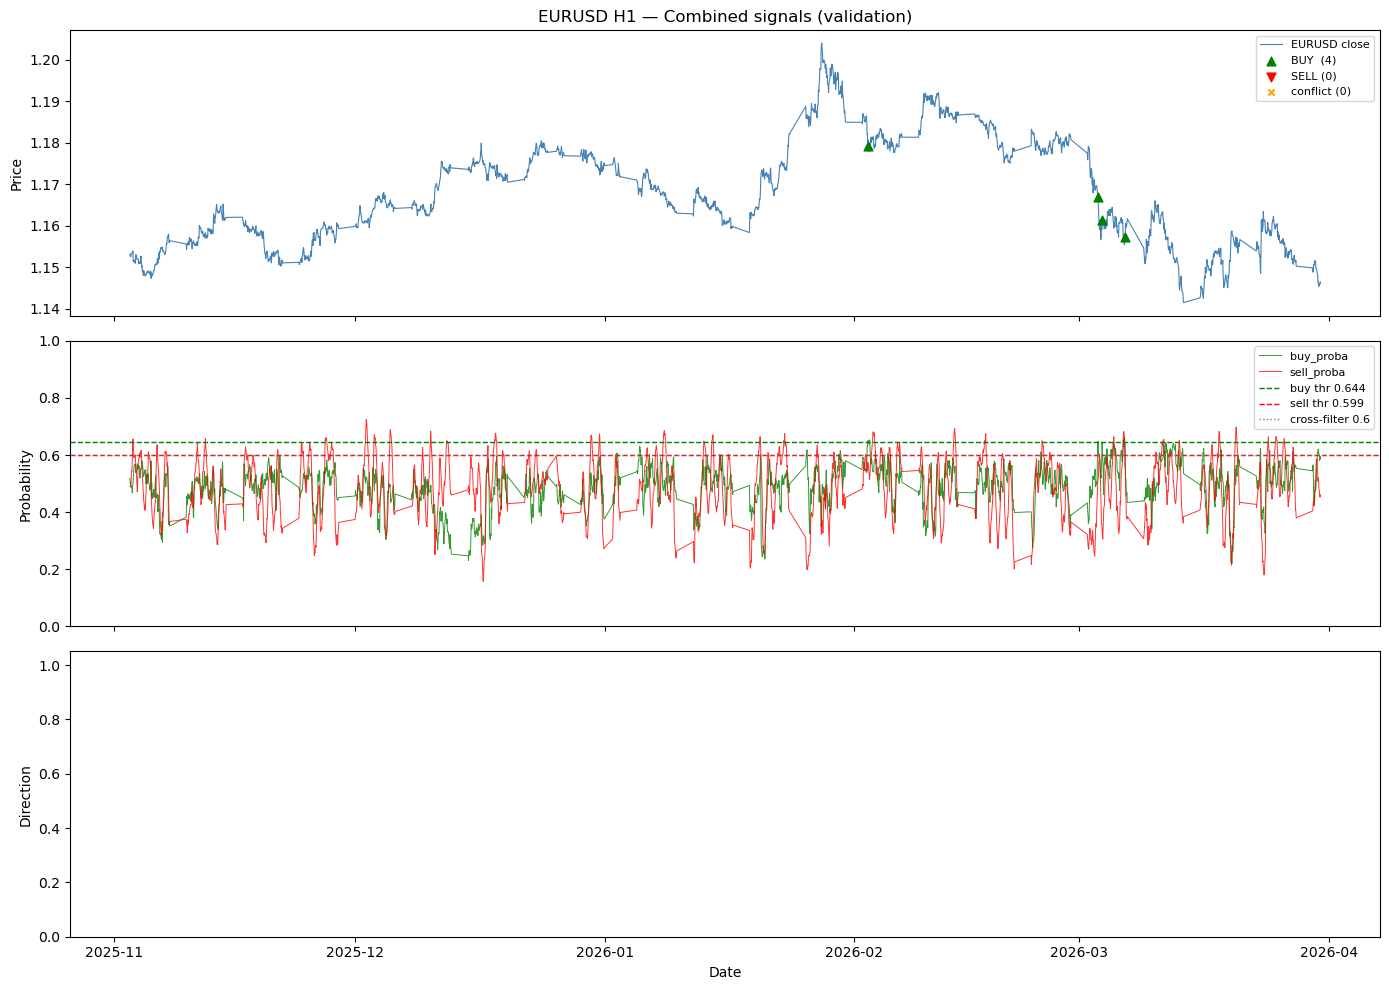

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates = val_combined["datetime"]

# Panel 1: close price + signal markers
ax = axes[0]
ax.plot(dates, val_combined["close"], color="steelblue", lw=0.8, label="EURUSD close")
buy_bars  = val_combined[val_combined["buy_signal"]  == 1]
sell_bars = val_combined[val_combined["sell_signal"] == 1]
conf_bars = val_combined[val_combined["conflict"]    == 1]
ax.scatter(buy_bars["datetime"],  buy_bars["close"],  marker="^", color="green",  s=40, zorder=5, label=f"BUY  ({len(buy_bars)})")
ax.scatter(sell_bars["datetime"], sell_bars["close"], marker="v", color="red",    s=40, zorder=5, label=f"SELL ({len(sell_bars)})")
ax.scatter(conf_bars["datetime"], conf_bars["close"], marker="x", color="orange", s=20, zorder=4, label=f"conflict ({len(conf_bars)})")
ax.set_ylabel("Price")
ax.set_title(f"{PAIR} {TIMEFRAME} — Combined signals (validation)")
ax.legend(fontsize=8)

# Panel 2: buy_proba and sell_proba
ax = axes[1]
ax.plot(dates, val_combined["buy_proba"],  color="green", lw=0.7, alpha=0.8, label="buy_proba")
ax.plot(dates, val_combined["sell_proba"], color="red",   lw=0.7, alpha=0.8, label="sell_proba")
ax.axhline(BUY_THRESHOLD,  color="green", linestyle="--", lw=1, label=f"buy thr {BUY_THRESHOLD:.3f}")
ax.axhline(SELL_THRESHOLD, color="red",   linestyle="--", lw=1, label=f"sell thr {SELL_THRESHOLD:.3f}")
ax.axhline(CROSS_FILTER,   color="gray",  linestyle=":",  lw=1, label=f"cross-filter {CROSS_FILTER}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: direction
direction_map = {"neutral": 0, "buy": 1, "sell": -1, "conflict": 0.5}
ax = axes[2]
colors = val_combined["direction"].map({"buy":"green","sell":"red","conflict":"orange","neutral":"lightgray"})
ax.bar(dates, val_combined["direction"].map({"buy":1,"sell":-1,"conflict":0.5,"neutral":0}),
       color=colors, width=0.03)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Direction")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()


## 8. Export — Test Set Signals

The test set is the final hold-out. We apply the combiner here to produce the signal output
that would be consumed by the agent pipeline in production.


In [20]:
test_combined = apply_conflict_filter(
    test_scores, BUY_THRESHOLD, SELL_THRESHOLD, CROSS_FILTER,
    buy_only=BUY_ONLY
)
test_combined = apply_cooldown(test_combined, COOLDOWN_BARS)

td_test = len(test_combined) / 24

print(f"=== Test set ({len(test_combined):,} bars | {td_test:.0f} trading days) ===")
print(f"BUY  signals : {test_combined['buy_signal'].sum()}  ({test_combined['buy_signal'].sum()/td_test:.2f}/day)")
print(f"SELL signals : {test_combined['sell_signal'].sum()}  ({test_combined['sell_signal'].sum()/td_test:.2f}/day)")
print(f"Conflicts    : {test_combined['conflict'].sum()}")

OUTPUT_DIR = ROOT / "data" / "signals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUTPUT_DIR / f"{PAIR}_{TIMEFRAME}_combined_signals_test.csv"
test_combined.to_csv(out_path, index=False)
print(f"\n✓ Saved → {out_path}")

display(test_combined[test_combined["direction"] != "neutral"].head(30))


=== Test set (1,624 bars | 68 trading days) ===
BUY  signals : 28  (0.41/day)
SELL signals : 0  (0.00/day)
Conflicts    : 0

✓ Saved → C:\Users\dsosa\Documents\fx-prival\ml-signal-service\data\signals\EURUSD_H1_combined_signals_test.csv


,datetime,close,session_london,session_ny,buy_proba,sell_proba,conflict,buy_signal,sell_signal,direction
383,2026-04-22 23:00:00,1.17040,0,0,0.655331,0.479939,0,1,0,buy
556,2026-05-04 04:00:00,1.17243,0,0,0.657847,0.469251,0,1,0,buy
731,2026-05-13 11:00:00,1.17018,1,0,0.647489,0.599433,0,1,0,buy
790,2026-05-15 22:00:00,1.16208,0,0,0.679461,0.313677,0,1,0,buy
813,2026-05-18 21:00:00,1.16285,0,1,0.655804,0.400157,0,1,0,buy
818,2026-05-19 02:00:00,1.16542,0,0,0.650588,0.409150,0,1,0,buy
831,2026-05-19 15:00:00,1.16165,1,1,0.658036,0.598967,0,1,0,buy
1048,2026-06-01 16:00:00,1.16093,0,1,0.648475,0.556452,0,1,0,buy
1163,2026-06-08 11:00:00,1.15076,1,0,0.646303,0.451275,0,1,0,buy
1169,2026-06-08 17:00:00,1.15421,0,1,0.699824,0.393734,0,1,0,buy


## 9. Test Set Evaluation — Sealed Hold-Out

The test set (2026-02-02 → 2026-07-03) is the final arbiter. We evaluate precision
on this untouched window to detect overfitting. Validation results are useful for
calibration, but **test results determine whether the strategy is production-ready**.


In [21]:
# Merge labels into test_combined
test_with_labels = test_combined.merge(
    df_features[["datetime", "buy_label", "sell_label"]],
    on="datetime", how="left"
)
test_with_labels.dropna(subset=["buy_label", "sell_label"], inplace=True)
test_with_labels.reset_index(drop=True, inplace=True)

td_test = len(test_with_labels) / 24

# Validation reference (val_combined already has labels from Section 6)
p_val_buy,  n_val_buy  = precision(val_combined["buy_signal"],  val_combined["buy_label"])
p_val_sell, n_val_sell = precision(val_combined["sell_signal"], val_combined["sell_label"])
total_val = n_val_buy + n_val_sell
correct_val = int(
    ((val_combined["buy_signal"]  == 1) & (val_combined["buy_label"]  == 1) |
     (val_combined["sell_signal"] == 1) & (val_combined["sell_label"] == 1)).sum()
)
p_val = round(correct_val / total_val, 3) if total_val > 0 else float("nan")
td_val = len(val_combined) / 24

print(f"=== Test Set ({len(test_with_labels):,} bars | {td_test:.0f} trading days) ===")
print(f"Breakeven precision: {breakeven:.3f}  (R:R = 1:{ATR_TP/ATR_SL})")
print()
print(f"{'Signal':<30} {'Precision':>10}  {'Signals':>9}  {'Per day':>8}")
print("-" * 65)

p, n = precision(test_with_labels["buy_signal"], test_with_labels["buy_label"])
print(f"{'BUY  final':<30} {p:>10.3f}  {n:>9}  {n/td_test:>7.2f}")

p, n = precision(test_with_labels["sell_signal"], test_with_labels["sell_label"])
print(f"{'SELL final':<30} {p:>10.3f}  {n:>9}  {n/td_test:>7.2f}")

total = int(test_with_labels["buy_signal"].sum() + test_with_labels["sell_signal"].sum())
correct = int(
    ((test_with_labels["buy_signal"]  == 1) & (test_with_labels["buy_label"]  == 1) |
     (test_with_labels["sell_signal"] == 1) & (test_with_labels["sell_label"] == 1)).sum()
)
p_combined = round(correct / total, 3) if total > 0 else float("nan")
print()
print(f"{'COMBINED final':<30} {p_combined:>10.3f}  {total:>9}  {total/td_test:>7.2f}")

print(f"\n=== Overfit Check ===")
print(f"{'Val  COMBINED':<30} {p_val:>10.3f}  {total_val:>9}  {total_val/td_val:>7.2f}")
print(f"{'Test COMBINED':<30} {p_combined:>10.3f}  {total:>9}  {total/td_test:>7.2f}")
print(f"{'Gap (val - test)':<30} {p_val-p_combined:>+10.3f}")
print(f"{'Overfit?':<30} {'YES - gap > 0.05' if p_val-p_combined > 0.05 else 'Acceptable'}")


=== Test Set (1,618 bars | 67 trading days) ===
Breakeven precision: 0.400  (R:R = 1:1.5)

Signal                          Precision    Signals   Per day
-----------------------------------------------------------------
BUY  final                          0.286         28     0.42
SELL final                            nan          0     0.00

COMBINED final                      0.286         28     0.42

=== Overfit Check ===
Val  COMBINED                       0.250          4     0.04
Test COMBINED                       0.286         28     0.42
Gap (val - test)                   -0.036
Overfit?                       Acceptable


In [22]:
# Cross-filter sweep on test set
test_scores_with_labels = test_scores.merge(
    df_features[["datetime", "buy_label", "sell_label"]],
    on="datetime", how="left"
)
test_scores_with_labels.dropna(subset=["buy_label", "sell_label"], inplace=True)
test_scores_with_labels.reset_index(drop=True, inplace=True)

print(f"Cross-filter sweep on test set ({len(test_scores_with_labels):,} bars)")
print()
print(f"{'CF':>6}  {'BUY prec':>9}  {'BUY n':>6}  {'/day':>6}  {'SELL prec':>10}  {'SELL n':>7}  {'/day':>6}  {'COMB prec':>10}  {'COMB n':>7}  {'/day':>6}")
print("-" * 95)

for cf in [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]:
    tmp = apply_conflict_filter(test_scores_with_labels, BUY_THRESHOLD, SELL_THRESHOLD, cf, buy_only=BUY_ONLY, session_filter=SESSION_FILTER)
    tmp = apply_cooldown(tmp, COOLDOWN_BARS)

    p_b, n_b = precision(tmp["buy_signal"], tmp["buy_label"])
    p_s, n_s = precision(tmp["sell_signal"], tmp["sell_label"])
    total_n = n_b + n_s
    correct_n = int(
        ((tmp["buy_signal"]  == 1) & (tmp["buy_label"]  == 1) |
         (tmp["sell_signal"] == 1) & (tmp["sell_label"] == 1)).sum()
    )
    p_c = round(correct_n / total_n, 3) if total_n > 0 else float("nan")

    b_mark = "" if (p_b or 0) >= breakeven else " *"
    s_mark = "" if (p_s or 0) >= breakeven else " *"
    c_mark = "" if (p_c or 0) >= breakeven else " *"
    sel = " <--" if cf == CROSS_FILTER else ""

    print(f"{cf:>5.2f}{sel:<4}  {p_b or 0:>8.3f}{b_mark:<2}  {n_b:>6}  {n_b/td_test:>5.2f}  {p_s or 0:>9.3f}{s_mark:<2}  {n_s:>7}  {n_s/td_test:>5.2f}  {p_c or 0:>9.3f}{c_mark:<2}  {total_n:>7}  {total_n/td_test:>5.2f}")

print()
print(f"* = below breakeven ({breakeven:.3f})")
print(f"Selected CROSS_FILTER = {CROSS_FILTER} (from validation calibration)")


Cross-filter sweep on test set (1,618 bars)

    CF   BUY prec   BUY n    /day   SELL prec   SELL n    /day   COMB prec   COMB n    /day
-----------------------------------------------------------------------------------------------
 0.80         0.400        30   0.44        nan *        0   0.00      0.400         30   0.44
 0.75         0.400        30   0.44        nan *        0   0.00      0.400         30   0.44
 0.70         0.400        30   0.44        nan *        0   0.00      0.400         30   0.44
 0.65         0.357 *      28   0.42        nan *        0   0.00      0.357 *       28   0.42
 0.60 <--     0.364 *      22   0.33        nan *        0   0.00      0.364 *       22   0.33
 0.55         0.300 *      10   0.15        nan *        0   0.00      0.300 *       10   0.15


C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.


 0.50         0.400         5   0.07        nan *        0   0.00      0.400          5   0.07
 0.45         0.400         5   0.07        nan *        0   0.00      0.400          5   0.07
 0.40         0.000 *       3   0.04        nan *        0   0.00      0.000 *        3   0.04
 0.35         0.000 *       1   0.01        nan *        0   0.00      0.000 *        1   0.01
 0.30         0.000 *       1   0.01        nan *        0   0.00      0.000 *        1   0.01

* = below breakeven (0.400)
Selected CROSS_FILTER = 0.6 (from validation calibration)


C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.at[i, "buy_signal"] = 0   # too close to previous BUY -> suppress
C:\Users\dsosa\AppData\Local\Temp\ipykernel_26312\3032542236.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.


### 9.1 Side-by-Side: BUY+SELL vs BUY-only

Does the SELL lane add value, or is a BUY-only strategy equivalent?
We compare the combined dual-model approach against using only the BUY model
at various cross-filter strengths.


In [23]:
print(f"{'Strategy':<40} {'Precision':>9}  {'Signals':>7}  {'/day':>6}")
print("-" * 70)

# BUY+SELL combined (current approach)
print(f"{'BUY+SELL combined (cf=' + str(CROSS_FILTER) + ')':<40} {p_combined:>9.3f}  {total:>7}  {total/td_test:>6.2f}")

# BUY-only: no cross-filter, just threshold + cooldown
test_buy_only = test_scores_with_labels.copy()
test_buy_only["buy_signal"] = (test_buy_only["buy_proba"] >= BUY_THRESHOLD).astype(int)
test_buy_only["sell_signal"] = 0
test_buy_only["conflict"] = 0
test_buy_only["direction"] = "neutral"
test_buy_only.loc[test_buy_only["buy_signal"] == 1, "direction"] = "buy"
test_buy_only = apply_cooldown(test_buy_only, COOLDOWN_BARS)
p_bo, n_bo = precision(test_buy_only["buy_signal"], test_buy_only["buy_label"])
print(f"{'BUY-only (no cross-filter)':<40} {p_bo:>9.3f}  {n_bo:>7}  {n_bo/td_test:>6.2f}")

print()

# BUY-only with cross-filter sweep
print(f"{'BUY-only cf':>12}  {'Precision':>9}  {'Signals':>7}  {'/day':>6}")
print("-" * 40)

best_cf = None
best_prec = 0

for cf in [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]:
    tmp = test_scores_with_labels.copy()
    tmp["buy_signal"] = (
        (tmp["buy_proba"] >= BUY_THRESHOLD) &
        (tmp["sell_proba"] < cf)
    ).astype(int)
    tmp["sell_signal"] = 0
    tmp["conflict"] = 0
    tmp["direction"] = "neutral"
    tmp.loc[tmp["buy_signal"] == 1, "direction"] = "buy"
    tmp = apply_cooldown(tmp, COOLDOWN_BARS)

    p, n = precision(tmp["buy_signal"], tmp["buy_label"])
    mark = " <-- best" if p and p > best_prec else ""
    if p and p > best_prec:
        best_prec = p
        best_cf = cf
    be_mark = "  ABOVE breakeven" if (p or 0) >= breakeven else ""
    print(f"{cf:>11.2f}  {p or 0:>9.3f}  {n:>7}  {n/td_test:>6.2f}{mark}{be_mark}")

print(f"\nBreakeven: {breakeven:.3f}")
if best_cf is not None:
    print(f"BUY-only best: cf={best_cf:.2f}  prec={best_prec:.3f}")
else:
    print("BUY-only: never crosses breakeven with any cross-filter")


Strategy                                 Precision  Signals    /day
----------------------------------------------------------------------
BUY+SELL combined (cf=0.6)                   0.286       28    0.42
BUY-only (no cross-filter)                   0.237       38    0.56

 BUY-only cf  Precision  Signals    /day
----------------------------------------
       0.80      0.237       38    0.56 <-- best
       0.75      0.237       38    0.56
       0.70      0.237       38    0.56
       0.65      0.250       36    0.53 <-- best
       0.60      0.286       28    0.42 <-- best
       0.55      0.176       17    0.25
       0.50      0.200       10    0.15
       0.45      0.250        8    0.12
       0.40      0.000        6    0.09
       0.35      0.000        3    0.04
       0.30      0.000        1    0.01

Breakeven: 0.400
BUY-only best: cf=0.60  prec=0.286


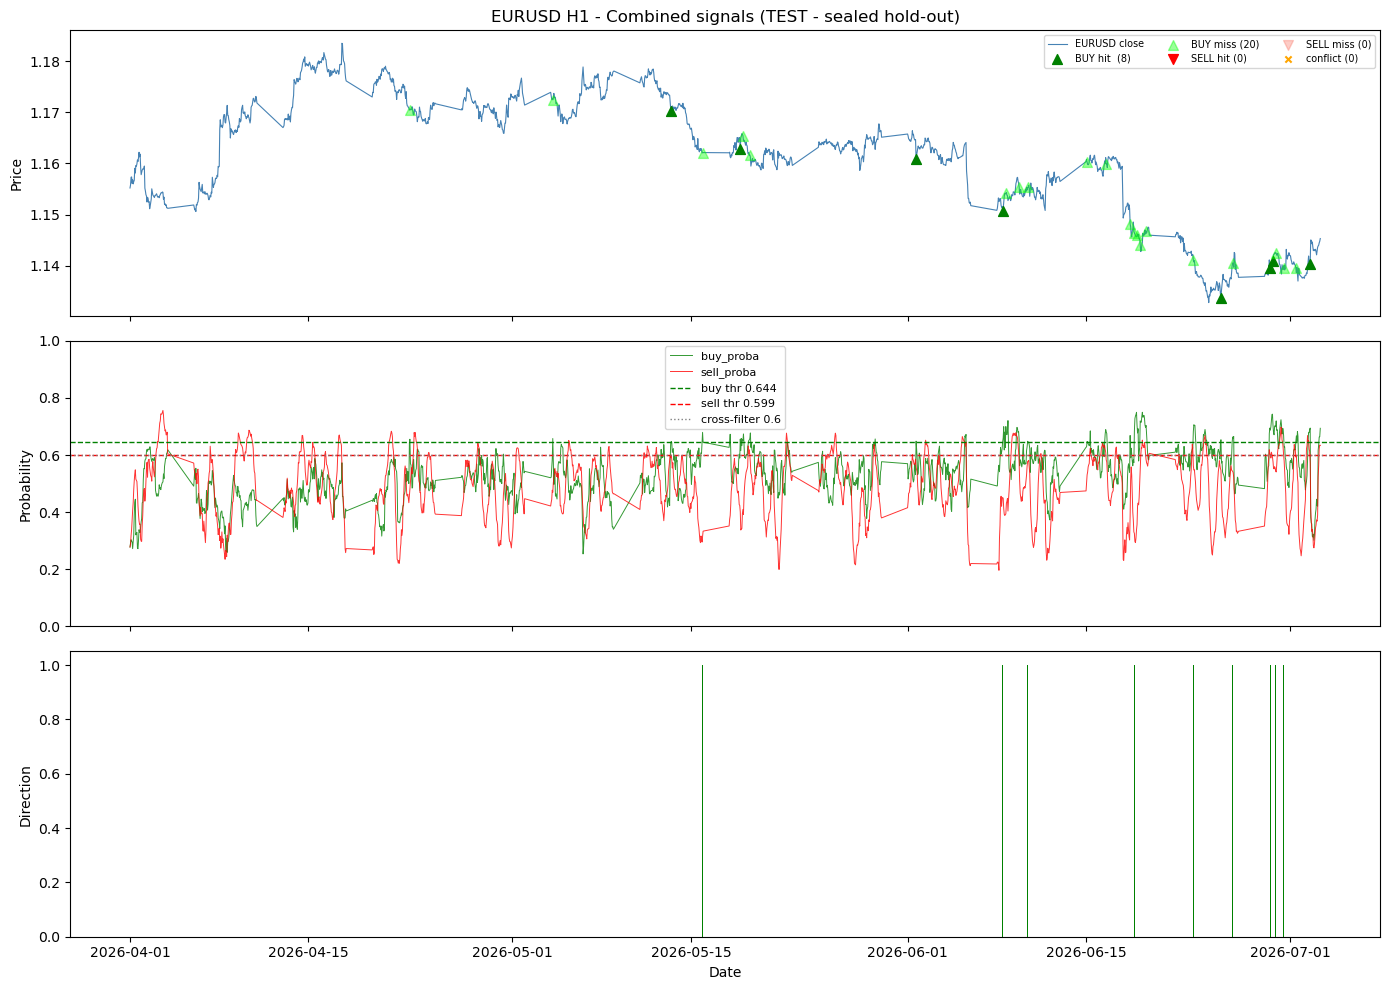

Test period: 2026-04-01 to 2026-07-03
Total signals: 28  |  Hits: 8  |  Precision: 0.286


In [24]:
# Test set visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

dates = test_with_labels["datetime"]

# Panel 1: close price + signal markers
ax = axes[0]
ax.plot(dates, test_with_labels["close"], color="steelblue", lw=0.8, label="EURUSD close")
buy_bars  = test_with_labels[test_with_labels["buy_signal"]  == 1]
sell_bars = test_with_labels[test_with_labels["sell_signal"] == 1]
conf_bars = test_with_labels[test_with_labels["conflict"]    == 1]

buy_hits  = buy_bars[buy_bars["buy_label"] == 1]
buy_miss  = buy_bars[buy_bars["buy_label"] == 0]
sell_hits = sell_bars[sell_bars["sell_label"] == 1]
sell_miss = sell_bars[sell_bars["sell_label"] == 0]

ax.scatter(buy_hits["datetime"],  buy_hits["close"],  marker="^", color="green",  s=50, zorder=5, label=f"BUY hit  ({len(buy_hits)})")
ax.scatter(buy_miss["datetime"],  buy_miss["close"],  marker="^", color="lime",   s=50, zorder=5, alpha=0.4, label=f"BUY miss ({len(buy_miss)})")
ax.scatter(sell_hits["datetime"], sell_hits["close"], marker="v", color="red",    s=50, zorder=5, label=f"SELL hit ({len(sell_hits)})")
ax.scatter(sell_miss["datetime"], sell_miss["close"], marker="v", color="salmon",  s=50, zorder=5, alpha=0.4, label=f"SELL miss ({len(sell_miss)})")
ax.scatter(conf_bars["datetime"], conf_bars["close"], marker="x", color="orange", s=20, zorder=4, label=f"conflict ({len(conf_bars)})")
ax.set_ylabel("Price")
ax.set_title(f"{PAIR} {TIMEFRAME} - Combined signals (TEST - sealed hold-out)")
ax.legend(fontsize=7, ncol=3)

# Panel 2: buy_proba and sell_proba
ax = axes[1]
ax.plot(dates, test_with_labels["buy_proba"],  color="green", lw=0.7, alpha=0.8, label="buy_proba")
ax.plot(dates, test_with_labels["sell_proba"], color="red",   lw=0.7, alpha=0.8, label="sell_proba")
ax.axhline(BUY_THRESHOLD,  color="green", linestyle="--", lw=1, label=f"buy thr {BUY_THRESHOLD:.3f}")
ax.axhline(SELL_THRESHOLD, color="red",   linestyle="--", lw=1, label=f"sell thr {SELL_THRESHOLD:.3f}")
ax.axhline(CROSS_FILTER,   color="gray",  linestyle=":",  lw=1, label=f"cross-filter {CROSS_FILTER}")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel 3: direction
ax = axes[2]
colors = test_with_labels["direction"].map({"buy":"green","sell":"red","conflict":"orange","neutral":"lightgray"})
ax.bar(dates, test_with_labels["direction"].map({"buy":1,"sell":-1,"conflict":0.5,"neutral":0}),
       color=colors, width=0.03)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Direction")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

print(f"Test period: {dates.min().strftime('%Y-%m-%d')} to {dates.max().strftime('%Y-%m-%d')}")
print(f"Total signals: {total}  |  Hits: {correct}  |  Precision: {p_combined}")
